# Проект. Исследование стартапов


- Автор: Деньгина Анна
- Дата: 24.09.2026

<a id=""></a>
## Введение

**Цель проекта:** провести исследовательский анализ рынка стартапов и определить, в какую отрасль и с каким типом финансирования целесообразно инвестировать в 2015 году.

**Задачи проекта:**

1. Загрузить и предобработать данные: оценить объём, типы, пропуски и дубликаты, привести столбцы к единому стилю, обработать `funding_total_usd` и даты, заполнить пропуски в `mid_funding_at` и удалить неинформативные строки.

2. Провести инжиниринг признаков: разделить компании по срокам финансирования, выделить массовые, средние и нишевые сегменты и визуализировать соотношения.

3. Проанализировать выбросы: определить типичный размер финансирования, найти аномалии методом IQR по сегментам, исключить аномальные компании и отфильтровать годы с 50+ раундами. 

4. Изучить типы финансирования: сравнить объём и популярность, выделить закономерности и построить график возвратов.

5. Проанализировать динамику: рассчитать средний раунд, построить графики по годам, выявить растущие сегменты и рассчитать нормированные возвраты.

6. Сделать итоговый вывод и дать рекомендацию по отрасли и типу финансирования на 2015 год.

## Содержание

1. [Шаг 1. Знакомство с данными](#step1)
2. [Шаг 2. Инжиниринг признаков](#step2)
3. [Шаг 3. Работа с выбросами](#step3)
4. [Шаг 4. Анализ динамики](#step4)
5. [Шаг 5. Итоговый вывод](#step5)

---

<a id="step1"></a>
## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

---

### 1.1. Вывод общей информации

Загрузим все необходимые для анализа библиотеки:

In [1]:
# Импортируем библиотеки
import pandas as pd
# Настройка отображения чисел: разделители тысяч, 2 знака после запятой
pd.options.display.float_format = '{:,.2f}'.format
import numpy as np
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

---
В данном блоке содержатся часто используемые функции и их описание:

In [2]:
def value_counts_summary(df, column):
    """
    Возвращает таблицу с количеством и долей (%) по значениям столбца.
    Параметры:
    df - датафрейм
    column - название столбца (строка)
    """
    counts = df[column].value_counts()
    percent = (df[column].value_counts(normalize=True) * 100).round(2)
    
    summary = pd.DataFrame({
        'Количество': counts,
        'Доля, %': percent
    }).sort_values('Количество', ascending=False)
    
    return summary

In [3]:
def plot_pie(data, title, colors=None):
    """
    Строит круговую диаграмму по данным.
    
    Параметры:
    data — Series с данными (индекс — категории, значения — числа).
    title — заголовок графика.
    colors — список цветов (по умолчанию ['royalblue', 'cornflowerblue', 'lightblue']).
    """
    if colors is None:
        colors = ['royalblue', 'cornflowerblue', 'lightblue']
    
    data.plot(
        kind='pie',
        autopct='%1.1f%%',
        figsize=(5, 5),
        colors=colors,
        startangle=90,
        title=title
    )
    plt.ylabel('')
    plt.show()

In [4]:
def plot_barh(data, title, xlabel='Количество', color='cornflowerblue', figsize=(8, 5)):
    """
    Строит горизонтальную столбчатую диаграмму.
    
    Параметры:
    data — Series (индекс — категории, значения — числа).
    title — заголовок графика.
    xlabel — подпись оси X.
    color — цвет столбцов.
    figsize — размер графика.
    """
    data_sorted = data.sort_values(ascending=True)
    
    plt.figure(figsize=figsize)
    data_sorted.plot(kind='barh', color=color, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

---
Загрузим данные датасетов в переменные `df_nv` и `df_ret`:

In [5]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_ret = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

**Проанализируем датасет `cb_investments`:**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  str    
 1   homepage_url          45989 non-null  str    
 2   category_list         45477 non-null  str    
 3    market               45477 non-null  str    
 4    funding_total_usd    49438 non-null  str    
 5   status                48124 non-null  str    
 6   country_code          44165 non-null  str    
 7   state_code            30161 non-null  str    
 8   region                44165 non-null  str    
 9   city                  43322 non-null  str    
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38554 no

Основной датасет `cb_investments.csv` содержит 40 столбцов и 54294 строки, в которых представлена информация о компаниях и состоявшемся финансировании.

Данные соответствуют описанию: есть информация о компаниях, их финансировании, датах и типах раундов.

Пропуски присутствуют во всех столбцах. Необходимо провести проверку, есть ли полностью пустые строки.

In [7]:
empty_rows = df.isna().all(axis=1).sum()
rows_before = df.shape[0]
print(f"Полностью пустых строк: {empty_rows}")

Полностью пустых строк: 4856


Найдено 4856 полностью пустых строк, принято решение удалить их.

In [8]:
df = df.dropna(how='all')
rows_after = df.shape[0]
rows_removed = rows_before - rows_after

print(f"Строк после удаления: {rows_after}")
print(f"Удалено строк: {rows_removed}")
print(f"Доля от исходного объема: {round(rows_removed*100/rows_before, 2)} %")

Строк после удаления: 49438
Удалено строк: 4856
Доля от исходного объема: 8.94 %


После удаления в датасете осталось 49 438 строк (удалено 4 856 строк, или 8,9% от исходного объёма). Выведем общую информацию и первые 5 строк датафрейма, чтобы продолжить оценку данных после удаления.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49438 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  str    
 1   homepage_url          45989 non-null  str    
 2   category_list         45477 non-null  str    
 3    market               45477 non-null  str    
 4    funding_total_usd    49438 non-null  str    
 5   status                48124 non-null  str    
 6   country_code          44165 non-null  str    
 7   state_code            30161 non-null  str    
 8   region                44165 non-null  str    
 9   city                  43322 non-null  str    
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38554 no

In [10]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


После удаления пустых строк в датасете осталось 49 438 строк и 40 столбцов.

- В названиях столбцов `market` и `funding_total_usd` присутствуют лишние пробелы, а столбцы `round_A`, `round_B`, `round_C`, `round_D`, `round_E`, `round_F`, `round_G` и `round_H` можно привести к нижнему регистру.

- Пропуски сохраняются в 15 столбцах:  `name`, `homepage_url`, `category_list`, `market`, `status`, `country_code`, `state_code`, `region`, `city`, `participants`, `founded_at`, `founded_month`, `founded_quarter`, `founded_year`, `mid_funding_at`.

- 16 столбцов имеют тип данных `object`, `funding_total_usd` должен быть числовым. Требуется преобразование. Столбцы с датами: `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` нужно привести к `datetime`.

- Остальные 24 столбца имеют тип `float64`, преобразование не требуется.

**Проанализируем дополнительный датасет:**

In [11]:
df_ret.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [12]:
df_ret.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.00,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.00,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.00,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.00,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.00,2.19,3.38,0.00,0.55,0.00


Дополнительный датасет `cb_returns.csv` содержит 14 столбцов и 15 строк, в которых представлена информация о суммах возвратов по типам финансирования в миллионах долларов по годам.

- Названия столбцов уже в snake_case, лишних пробелов нет.

- Пропусков нет, все столбцы заполнены полностью.

- Столбец `year` имеет тип `int64`, остальные 13 столбцов `float64`, преобразований не требуется.

### 1.2. Предобработка данных

При проверке названий столбцов в обоих датасетах было выявлено, что большинство из них уже оформлены в стиле snake_case и точно отражают содержимое данных. Принято решение привести названия столбцов основного датасета к единому стилю, а именно -  убрать пробелы и перевести в нижний регистр.

In [13]:
# Приведем названия столбцов df к единому стилю
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='str')

Убираем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [14]:
# Убираем запятые и превращаем другие случайные символы в NaN
df['funding_total_usd'] = (
    df['funding_total_usd']
    .astype(str)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
# Выведем тип данных столбца после преобразования
df['funding_total_usd'].dtype

dtype('float64')

Обработаем типы данных в столбцах, которые хранят значения даты и времени:

In [15]:
# Список столбцов с датами
date_cols = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

# Изменяем тип данных
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Проверка после преобразования    
df[date_cols].dtypes

founded_at          datetime64[us]
first_funding_at    datetime64[us]
mid_funding_at      datetime64[us]
last_funding_at     datetime64[us]
dtype: object

В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

In [16]:
df_ret = df_ret.set_index('year')
df_ret.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.00,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.00,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.00,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.00,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.00,2.19,3.38,0.00,0.55,0.00


Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [17]:
# Список текстовых столбцов
text_cols = ['homepage_url', 'category_list', 'market', 
             'status', 'country_code', 'state_code', 'region', 'city']

# Заполняем пропуски заглушками
for col in text_cols:
    df[col] = df[col].fillna('unknown')

# Приводим к нижнему регистру, удаляем лишние пробелы
for col in text_cols:
    df[col] = df[col].str.strip().str.lower()
    
# Проверка
df[text_cols].isna().sum()

homepage_url     0
category_list    0
market           0
status           0
country_code     0
state_code       0
region           0
city             0
dtype: int64

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [18]:
print(f"Полных дубликатов: {df.duplicated().sum()}")

Полных дубликатов: 0


In [19]:
# Удаляем строки, где funding_total_usd NaN или 0
df = df.dropna(subset=['funding_total_usd'])
df = df[df['funding_total_usd'] > 0]

# Считаем
print(f"Строк после: {len(df)}")
print(f"Удалено строк на данном этапе: {rows_after-len(df)}")

Строк после: 40907
Удалено строк на данном этапе: 8531


Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

In [20]:
# Заполняем пропуски в mid_funding_at средним значением интервала
df['mid_funding_at'] = df['mid_funding_at'].fillna(
    df['first_funding_at'] + (df['last_funding_at'] - df['first_funding_at']) / 2
)
missing = df['mid_funding_at'].isna().sum()

print(f"Пропусков в столбце mid_funding_at: {missing}")

Пропусков в столбце mid_funding_at: 0


Оценка полноты данных:

In [21]:
# Текущее количество строк
current_rows = df.shape[0]

# Отброшено
dropped = rows_before - current_rows
dropped_percent = round(dropped / rows_before * 100, 2)

print(f"Исходное количество строк: {rows_before}")
print(f"Осталось строк: {current_rows}")
print(f"Отброшено: {dropped} ({dropped_percent}%)")

Исходное количество строк: 54294
Осталось строк: 40907
Отброшено: 13387 (24.66%)


In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  str           
 1   homepage_url          40907 non-null  str           
 2   category_list         40907 non-null  str           
 3   market                40907 non-null  str           
 4   funding_total_usd     40907 non-null  float64       
 5   status                40907 non-null  str           
 6   country_code          40907 non-null  str           
 7   state_code            40907 non-null  str           
 8   region                40907 non-null  str           
 9   city                  40907 non-null  str           
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32201 non-null  datetime64[us]
 13  founded_month         32135 non-

### Промежуточный вывод:

- Исходный датасет содержал 54 294 строки. После удаления пустых строк, строк без данных о финансировании и обработки пропусков осталось 40 907 строк. Отброшено 13 387 строк (24,66%). Несмотря на то, что отброшена четверть данных, оставшегося объёма достаточно для решения задач проекта: ключевые столбцы `funding_total_usd`, `funding_rounds`, `first_funding_at` и `last_funding_at` заполнены, данные охватывают достаточный период.

- Названия столбцов приведены к единому стилю (snake_case, нижний регистр).

- Пропуски остались в 7 столбцах: `participants`, `founded_at`, `founded_month`, `founded_quarter`, `founded_year`, `first_funding_at` (2 значения) и `mid_funding_at` (1 значение).

- В столбце `funding_total_usd` убраны разделители разрядов, был приведён к float64.

- Даты `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` приведены к datetime.

- Пропуски в `mid_funding_at` заполнены серединой интервала между `first_funding_at` и `last_funding_at`.

- Текстовые пропуски заполнены заглушкой 'unknown'.

<a id="step2"></a>
## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

1. Группировка компаний по типу финансирования:

In [23]:
conditions = [
    df['funding_rounds'] == 1,
    (df['last_funding_at'] - df['first_funding_at']).dt.days <= 365
]
choices = [
    'Единичное финансирование',
    'Срок финансирования до года'
]

df['funding_group'] = np.select(
    conditions,
    choices,
    default='Срок финансирования более года'
)

In [24]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_group
0,Harvard University,http://harvard.edu,|education|,education,"90,000,000.00",operating,usa,ma,boston,cambridge,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Единичное финансирование
1,University of New Brunswick,http://www.unb.ca,unknown,unknown,"2,000,000.00",operating,unknown,unknown,unknown,unknown,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Единичное финансирование
2,DuPont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,"9,000,000.00",operating,usa,de,"wilmington, delaware",wilmington,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Единичное финансирование
3,University of Michigan,http://www.umich.edu/,|education|,education,"7,700,000.00",operating,usa,mi,detroit,ann arbor,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Срок финансирования до года
4,Case Western Reserve University,http://www.case.edu,|education|,education,"540,000.00",operating,usa,oh,cleveland,cleveland,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Единичное финансирование


In [25]:
chain_summary = value_counts_summary(df, 'funding_group')
chain_summary

,Количество,"Доля, %"
funding_group,,
Единичное финансирование,24113,58.95
Срок финансирования более года,12293,30.05
Срок финансирования до года,4501,11.00


Большинство компаний относится к группе единичного финансирования - 58.95% (24113 компаний). На втором месте - компании со сроком финансирования более года 30.05% (12293). Меньше всего компаний со сроком финансирования до года 11.00% (4501).

2. Визуализация соотношения групп финансирования по количеству компаний:

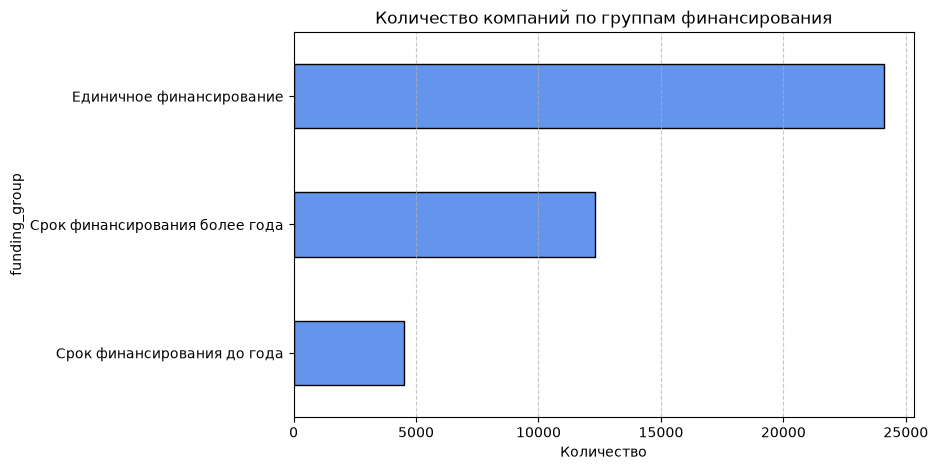

In [26]:
plot_barh(chain_summary['Количество'], 'Количество компаний по группам финансирования')

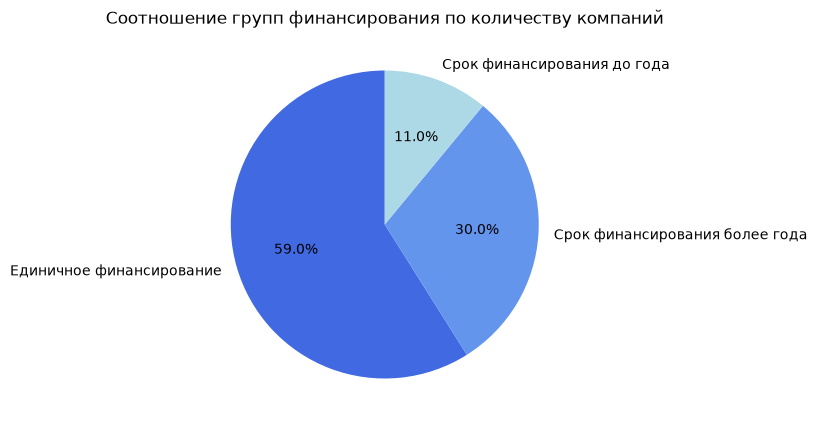

In [27]:
# Построение круговой диаграммы
plot_pie(chain_summary['Доля, %'], 'Соотношение групп финансирования по количеству компаний')

3. Визуализация соотношения групп финансирования по объему инвестиций:

In [28]:
# Объем финансирования по группам
total_funding = df.groupby('funding_group')['funding_total_usd'].sum()
total_funding

funding_group
Единичное финансирование         199,304,424,483.00
Срок финансирования более года   402,743,297,604.00
Срок финансирования до года       48,885,981,057.00
Name: funding_total_usd, dtype: float64

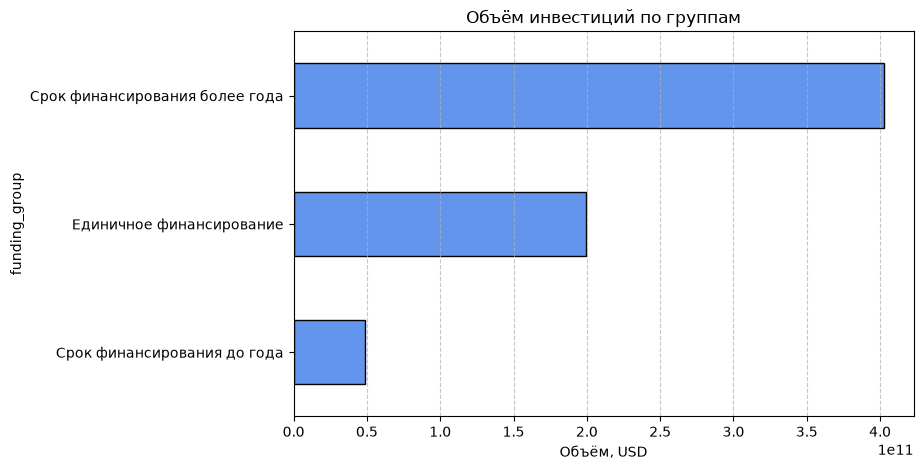

In [29]:
plot_barh(total_funding, 'Объём инвестиций по группам', xlabel='Объём, USD')

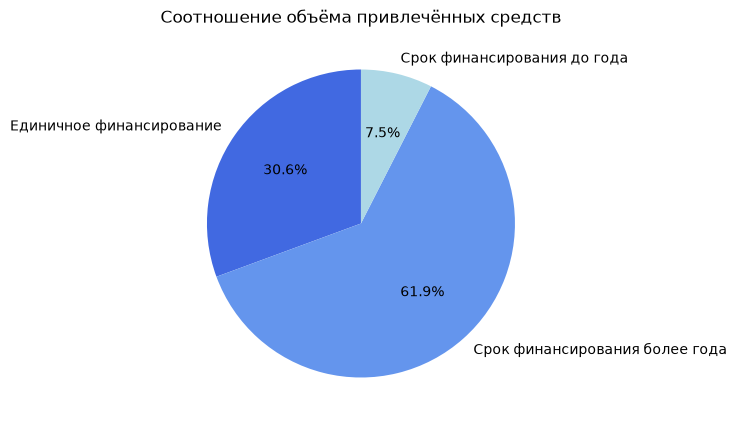

In [30]:
plot_pie(total_funding, 'Соотношение объёма привлечённых средств')

Наибольший объём финансирования приходится на группу «Срок финансирования более года» - 61.87%. На втором месте - «Единичное финансирование» 30.62%. Меньше всего у группы «Срок финансирования до года» 7.51%.

Интересно, что по количеству компаний лидирует «Единичное финансирование» (58.95%), но по объёму денег - «Срок более года». Это значит, что компании с длительным финансированием привлекают непропорционально больше средств.

### 2.2 Выделение средних и нишевых сегментов рынка

1. Рассчитаем количество уникальных сегментов в столбце `market`:

In [31]:
df['market'].nunique()

395

В столбце `market` содержится 395 уникальных сегментов. 

Для каждого сегмента рассчитаем количество компаний, разделим их на три категории: нишевый, средний и массовый

In [32]:
market_counts = df['market'].value_counts()

# Пороги категоризации сегментов рынка
MASSIVE_THRESHOLD = 120   # более 120 компаний — массовый
AVERAGE_THRESHOLD = 35    # от 35 до 120 — средний, менее 35 — нишевый

# Функция для категоризации сегментов
def market_category(count):
    if count > MASSIVE_THRESHOLD:
        return 'массовый'
    elif AVERAGE_THRESHOLD <= count <= MASSIVE_THRESHOLD:
        return 'средний'
    else:
        return 'нишевый'
# Применяем
market_categories = market_counts.apply(market_category)

# Считаем, сколько сегментов в каждой категории
count_markets = market_categories.value_counts()
count_markets

count
нишевый     289
средний      57
массовый     49
Name: count, dtype: int64

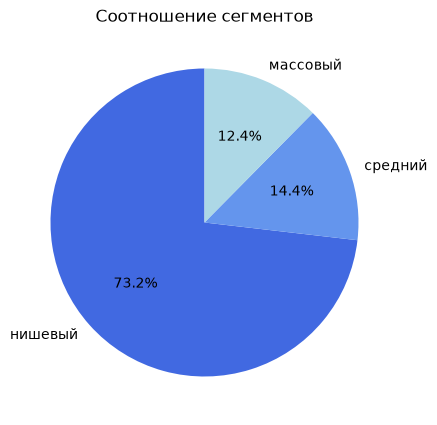

In [33]:
# Строим круговую диаграмму
plot_pie(count_markets, 'Соотношение сегментов')

2. Для построения графика распределения сегментов была выбрана гистограмма:

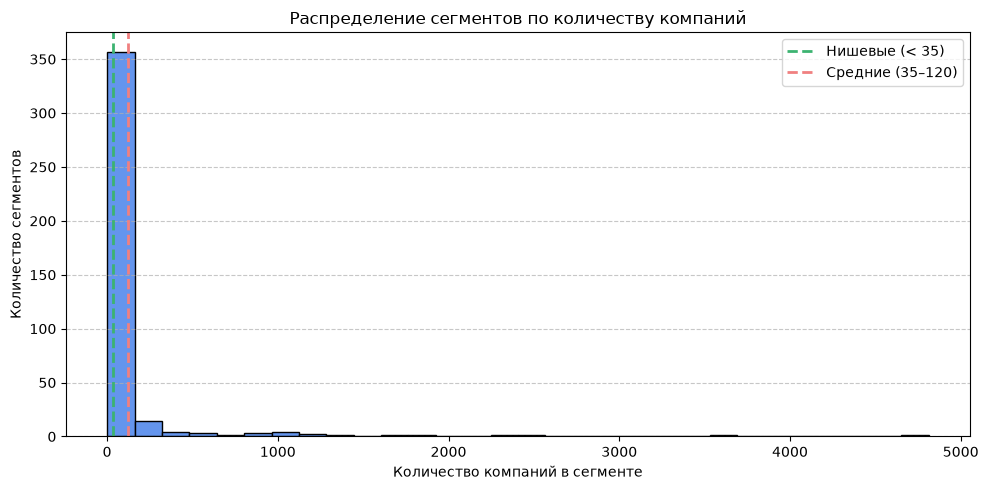

In [34]:
# Строим график распределения сегментов по количеству компаний
plt.figure(figsize=(10, 5))
plt.hist(market_counts, bins=30, color='cornflowerblue', edgecolor='black')
plt.title('Распределение сегментов по количеству компаний')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
# Границы категорий
plt.axvline(35, color='mediumseagreen', linestyle='--', linewidth=2, label='Нишевые (< 35)')
plt.axvline(120, color='lightcoral', linestyle='--', linewidth=2, label='Средние (35–120)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Для большей наглядности отобразим на графике распределение для нишевых и средних сегментов:

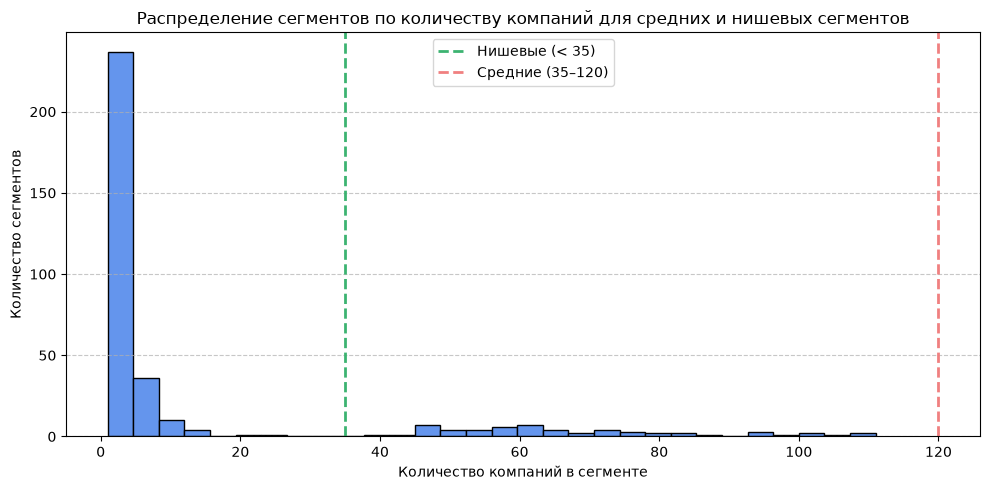

In [35]:
plt.figure(figsize=(10, 5))
plt.hist(market_counts[market_counts<=120], bins=30, color='cornflowerblue', edgecolor='black')
plt.title('Распределение сегментов по количеству компаний для средних и нишевых сегментов')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
# Границы категорий
plt.axvline(35, color='mediumseagreen', linestyle='--', linewidth=2, label='Нишевые (< 35)')
plt.axvline(120, color='lightcoral', linestyle='--', linewidth=2, label='Средние (35–120)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Полученные графики подтверждают, что большинство сегментов нишевые, то есть сегментов, в которых мало компаний, много.

3. Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

In [36]:
# Функция: возвращает имя сегмента, если он массовый, иначе - заглушку
def replace_market(market):
    count = market_counts.get(market, 0)
    if count > MASSIVE_THRESHOLD:
        return market  # массовый - оставляем как есть
    elif AVERAGE_THRESHOLD <= count <= MASSIVE_THRESHOLD:
        return 'mid'   # средний - заглушка
    else:
        return 'niche' # нишевый - заглушка

# Применяем
df['market'] = df['market'].apply(replace_market)

# Проверка
df['market'].value_counts()

market
software                4812
mid                     3841
biotechnology           3590
unknown                 2503
mobile                  2344
e-commerce              1866
curated web             1693
enterprise software     1381
health care             1185
clean technology        1180
games                   1117
advertising             1107
hardware + software     1062
social media            1003
health and wellness      873
education                844
niche                    830
finance                  828
analytics                667
manufacturing            596
security                 567
semiconductors           484
web hosting              424
consulting               349
hospitality              336
travel                   330
fashion                  303
news                     301
messaging                295
search                   291
real estate              279
saas                     272
music                    264
internet                 241
technol

В столбце market содержится 395 уникальных сегментов рынка. По количеству компаний в каждом сегменте они были разделены на три категории:

- Массовые (более 120 компаний) 49 сегментов(включая "unknown").

- Средние (от 35 до 120 компаний) 57 сегментов.

- Нишевые (менее 35 компаний) 289 сегментов.

Наибольшее количество сегментов относится к нишевым (289), наименьшее - к массовым (49). Это классическое распределение рынка: много мелких сегментов, мало крупных. Средние сегменты встречаются реже и образуют "хвост" распределения.

Отдельно стоит оговорить заглушку `unknown`. Она объединяет 2 503 компании, у которых рынок не был указан в исходных данных. Формально по числу компаний `unknown` попадает в категорию массовых (более 120), но это не реальный сегмент рынка, а техническая заглушка. В дальнейшем анализе:
- в разделе 3.2 при фильтрации годов и удалении аномалий `unknown` остаётся в данных (компании не удаляются), но не интерпретируется как отрасль;
- в разделе 4.2 при отборе растущих массовых сегментов заглушка `unknown` исключается вместе с `mid` и `niche`, чтобы не искажать выводы о реальных рынках.

Для дальнейшего анализа в столбце `market` оставлены только массовые сегменты. Все средние сегменты заменены на заглушку `mid` (3 841 компания), нишевые - на `niche` (830 компаний). Это позволяет рассматривать общие категории вместо 395 отдельных сегментов и упрощает анализ.

<a id="step3"></a>
## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

1. Рассмотрим статистические показатели столбца `funding_total_usd`:

In [37]:
df['funding_total_usd'].describe()

count           40,907.00
mean        15,912,526.05
std        168,678,800.17
min                  1.00
25%            350,000.00
50%          2,000,000.00
75%         10,000,000.00
max     30,079,503,000.00
Name: funding_total_usd, dtype: float64

Среднее (15.9 млн) в 8 раз больше медианы (2 млн), распределение сильно скошено вправо. Обнаружены аномальные данные: максимальное значение финансирования 30 млрд., минимальное 1.

2. Изучим распределение данных

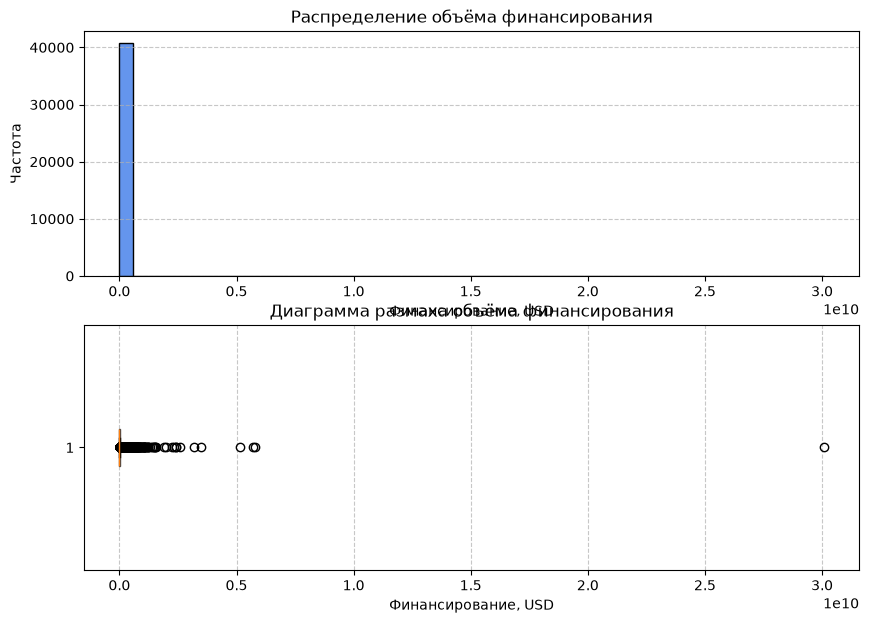

In [38]:
# Объединяем гистограмму и боксплот в одну фигуру
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# Строим гистограмму распределения
axes[0].hist(df['funding_total_usd'],
             bins=50, color='cornflowerblue', edgecolor='black')
axes[0].set_title('Распределение объёма финансирования')
axes[0].set_xlabel('Финансирование, USD')
axes[0].set_ylabel('Частота')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Строим "ящик с усами"
axes[1].boxplot(df['funding_total_usd'],
                orientation='horizontal', patch_artist=True,
                boxprops=dict(facecolor='cornflowerblue', alpha=0.7))
axes[1].set_title('Диаграмма размаха объёма финансирования')
axes[1].set_xlabel('Финансирование, USD')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

Распределение не наглядное из-за выбросов: ось X растянута до 30 млрд, а основная масса данных сжата в один столбец. Было принято решение использовать для визуализации 95-й перцентиль, он отсекает 5% экстремальных значений, но сохраняет типичные крупные компании.

In [39]:
# 95-й перцентиль
q95 = df['funding_total_usd'].quantile(0.95)
q95

np.float64(60000000.0)

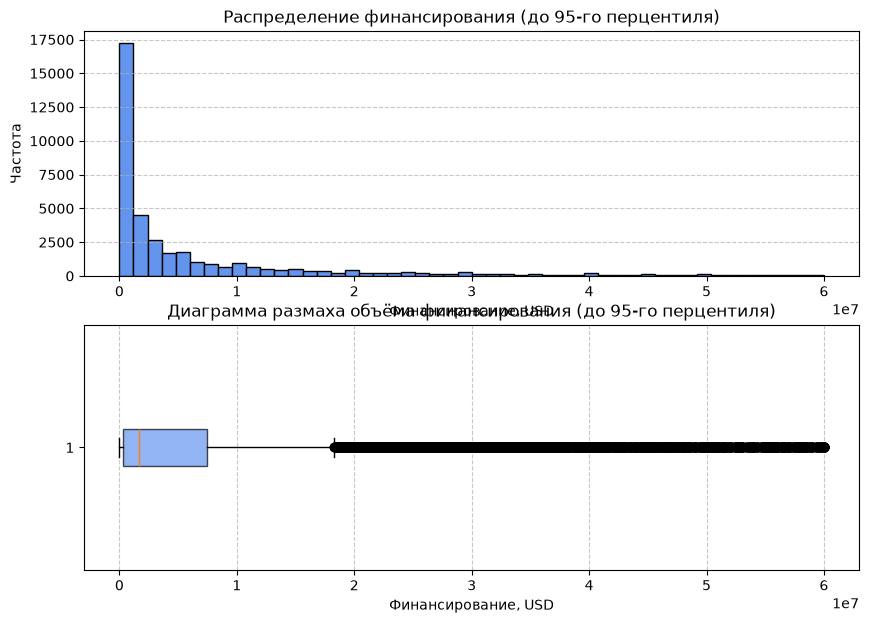

In [40]:
# Данные без выбросов
df_no_outliers = df[df['funding_total_usd'] <= q95]

# Объединяем гистограмму и боксплот в одну фигуру
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# Гистограмма без выбросов (до 95-го перцентиля)
axes[0].hist(df_no_outliers['funding_total_usd'],
             bins=50, color='cornflowerblue', edgecolor='black')
axes[0].set_title('Распределение финансирования (до 95-го перцентиля)')
axes[0].set_xlabel('Финансирование, USD')
axes[0].set_ylabel('Частота')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# "Ящик с усами"
axes[1].boxplot(df_no_outliers['funding_total_usd'],
                orientation='horizontal', patch_artist=True,
                boxprops=dict(facecolor='cornflowerblue', alpha=0.7))
axes[1].set_title('Диаграмма размаха объёма финансирования (до 95-го перцентиля)')
axes[1].set_xlabel('Финансирование, USD')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

По столбцу `funding_total_usd` видно, что распределение сильно скошено вправо: среднее (15.9 млн) значительно превышает медиану (2 млн). Типичный размер финансирования для одной компании от 350 тыс. до 10 млн (межквартильный размах). Значения выше 60 млн можно считать экстремальными выбросами. Минимальное значение (1) также является аномалией.

3. Определим компании с аномальным объёмом общего финансирования, используя метод IQR отдельно по каждому сегменту. 

In [41]:
# Функция для поиска выбросов по IQR
def iqr_outliers(group):
    """
    Помечает выбросы по методу IQR.
    Возвращает булеву серию: True — выброс, False — нет.
    """
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (group < lower) | (group > upper)

# Создаём столбец
df['is_outlier'] = False

# Считаем IQR для каждого сегмента
for market in df['market'].unique():
    mask = df['market'] == market
    df.loc[mask, 'is_outlier'] = iqr_outliers(df.loc[mask, 'funding_total_usd'])

# Проверка
print(f"Всего выбросов: {df['is_outlier'].sum()}")
print(df.groupby('market')['is_outlier'].sum())

Всего выбросов: 5244
market
advertising             136
analytics                82
apps                     32
automotive               22
big data                 23
biotechnology           382
clean technology        151
cloud computing          25
consulting               58
curated web             202
design                   15
e-commerce              269
education               112
enterprise software     146
entertainment            25
fashion                  40
finance                 104
games                   117
hardware + software     123
health and wellness     113
health care             128
hospitality              44
internet                 37
manufacturing            63
marketplaces             30
medical                  21
messaging                38
mid                     556
mobile                  309
music                    33
networking               22
news                     40
niche                   132
nonprofits               13
photography         

4. Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [42]:
outlier_summary = value_counts_summary(df, 'is_outlier')
outlier_summary

,Количество,"Доля, %"
is_outlier,,
False,35663,87.18
True,5244,12.82


87.18% компаний имеют типичный объём финансирования, 12.82% аномальный. 

In [43]:
# Сводная таблица: сегмент, количество аномалий, доля
outlier_summary = (
    df.groupby('market')['is_outlier']
    .agg(['sum', 'mean'])
    .rename(columns={'sum': 'Аномалий', 'mean': 'Доля'})
)

outlier_summary['Доля'] = (outlier_summary['Доля'] * 100).round(2)

# Сортируем
outlier_summary = outlier_summary.sort_values('Доля', ascending=False)

print(outlier_summary.head(10))

                 Аномалий  Доля
market                         
real estate            48 17.20
entertainment          25 16.67
consulting             58 16.62
search                 48 16.49
cloud computing        25 16.45
saas                   44 16.18
photography            33 16.18
technology             38 15.97
video                  30 15.96
niche                 132 15.90


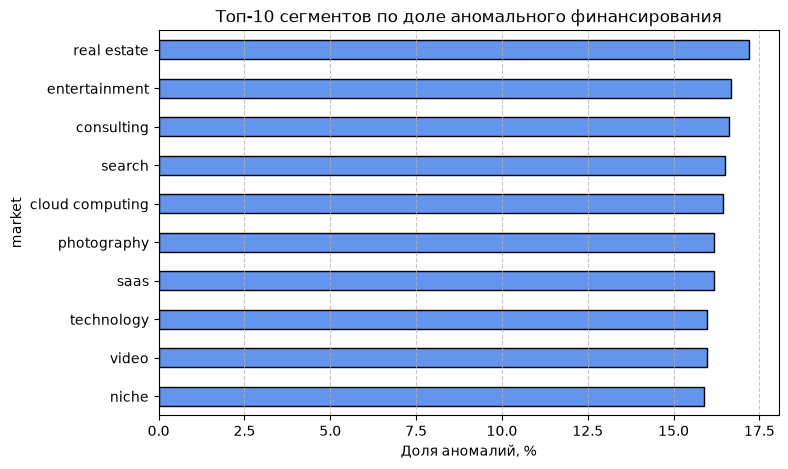

In [44]:
plot_barh(outlier_summary['Доля'].head(10).sort_values(ascending=True), 
          'Топ-10 сегментов по доле аномального финансирования', 
          'Доля аномалий, %')

Наибольшая доля компаний с аномальным финансированием в сегментах `real estate` (17.20%), `entertainment` (16.67%) и `consulting` (16.62%).

В целом доля аномалий в топ-10 сегментах находится в узком диапазоне 15.9-17.2%. Это говорит о том, что выбросы распределены по рынку равномерно и нет сегментов, где аномалии резко выделяются.

Сегмент `niche` также попал в топ (15.90%), что ожидаемо: в нём собраны компании из разных ниш с разным масштабом финансирования.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

1. Проверка полноты данных за 2014 год:

In [45]:
# Проверка по месяцам
monthly_2014 = df[df['mid_funding_at'].dt.year == 2014]
monthly_2014.groupby(monthly_2014['mid_funding_at'].dt.month)['funding_rounds'].sum()

mid_funding_at
1    893.00
2    715.00
3    810.00
4    807.00
5    761.00
6    900.00
7    779.00
8    636.00
9    595.00
10   524.00
11   314.00
12    23.00
Name: funding_rounds, dtype: float64

Данные за 2014 год неполные. Возможно, выгрузка была сделана в начале декабря 2014, поэтому последние 1,5-2 месяца попали в датасет частично или не попали вовсе.

2. Исключаем из датасета компании, у которых аномальное финансирование:

In [46]:
df_new = df.loc[df['is_outlier'] != True]
rows_before = df.shape[0]
rows_after = df_new.shape[0]

print(f"Строк до: {rows_before}")
print(f"Строк после: {rows_after}")
print(f"Удалено аномальных компаний: {rows_before - rows_after}")

Строк до: 40907
Строк после: 35663
Удалено аномальных компаний: 5244


Исключено 5 244 компании с аномальным финансированием (12.82% от исходного объёма). Осталось 35 663 строки в датафрейме `df_new`.

3. Оставляем данные только за те годы, когда было зафиксировано 50 или более раундов финансирования. 

In [47]:
# Считаем сумму раундов по годам
rounds_by_year = df_new.groupby(df_new['mid_funding_at'].dt.year)['funding_rounds'].sum()

# Годы с 50+ раундами
valid_years = rounds_by_year[rounds_by_year >= 50].index

print(f"Годы с 50+ раундами: {sorted(valid_years)}")

# Оставляем только эти годы
rows_before = df_new.shape[0]
df_new = df_new[df_new['mid_funding_at'].dt.year.isin(valid_years)]
rows_after = df_new.shape[0]
# Сохраняем год в отдельный столбец типа int
df_new['mid_funding_year'] = df_new['mid_funding_at'].dt.year.astype(int)

print(f"Строк до: {rows_before}")
print(f"Строк после: {rows_after}")
print(f"Удалено: {rows_before - rows_after}")

Годы с 50+ раундами: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Строк до: 35663
Строк после: 35588
Удалено: 75


После фильтрации остались данные за 2000-2014 годы, когда было зафиксировано 50 или более раундов финансирования. Удалено всего 75 строк, что говорит о том, что почти все компании в датасете получали финансирование в активные годы.

In [48]:
# Финальная сводка потерь от исходного объёма
initial_rows = 54294  # исходный датасет до всех чисток
final_rows = df_new.shape[0]

lost = initial_rows - final_rows
lost_percent = round(lost / initial_rows * 100, 2)

print(f"Исходный объём данных: {initial_rows}")
print(f"Осталось после всех фильтраций: {final_rows}")
print(f"Итого отброшено: {lost} ({lost_percent}%)")

Исходный объём данных: 54294
Осталось после всех фильтраций: 35588
Итого отброшено: 18706 (34.45%)


Несмотря на то, что отброшено больше трети исходного объёма, оставшихся данных достаточно для решения задач проекта: они охватывают период 2000-2014, ключевые столбцы заполнены, массовые сегменты представлены достаточным числом компаний.

### 3.3. Анализ типов финансирования по объёму и популярности

1. Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег:

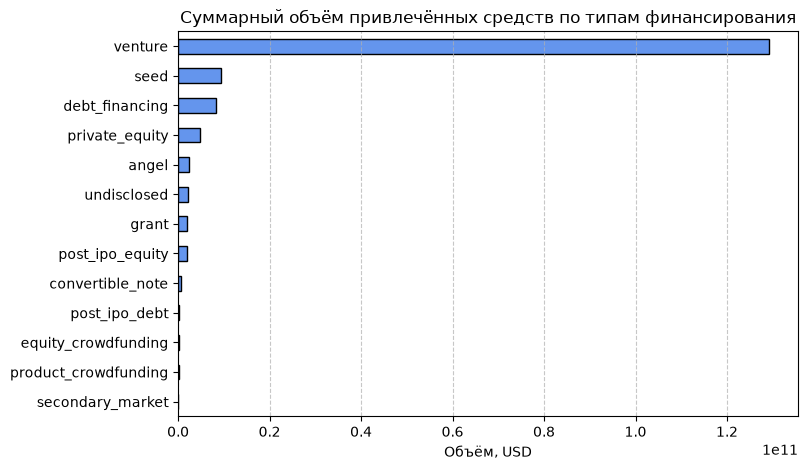

In [49]:
# Суммы по типам финансирования
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
                 'convertible_note', 'debt_financing', 'angel', 'grant',
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt',
                 'secondary_market', 'product_crowdfunding']

funding_sums = df_new[funding_types].sum().sort_values(ascending=True)

# График
plot_barh(funding_sums, 
          'Суммарный объём привлечённых средств по типам финансирования', 
          'Объём, USD')

2. Построим график, который отображает популярность разных типов финансирования (кол-во):

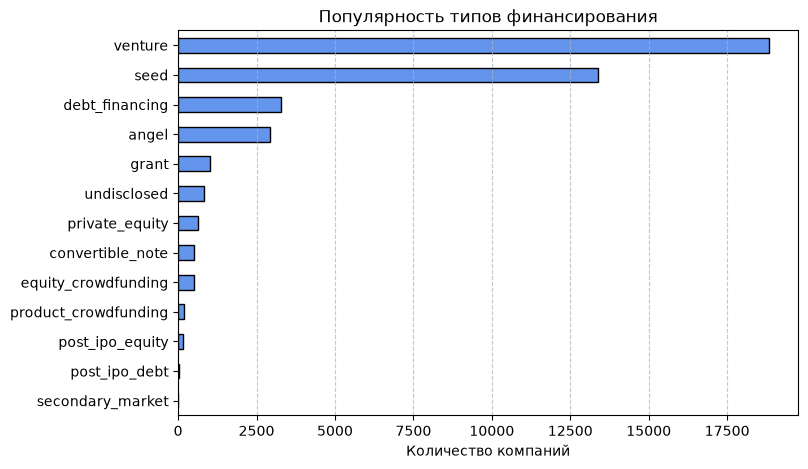

In [50]:
# Считаем количество компаний, у которых тип > 0
funding_popularity = (df_new[funding_types] > 0).sum().sort_values(ascending=True)

# График
plot_barh(funding_popularity, 
          'Популярность типов финансирования', 
          'Количество компаний')


3. Чтобы наглядно увидеть разницу между объёмом привлечённых средств и частотой использования каждого типа финансирования, сопоставим графики. Это позволит выделить типы, которые часто используются, но дают малый объём, и наоборот.

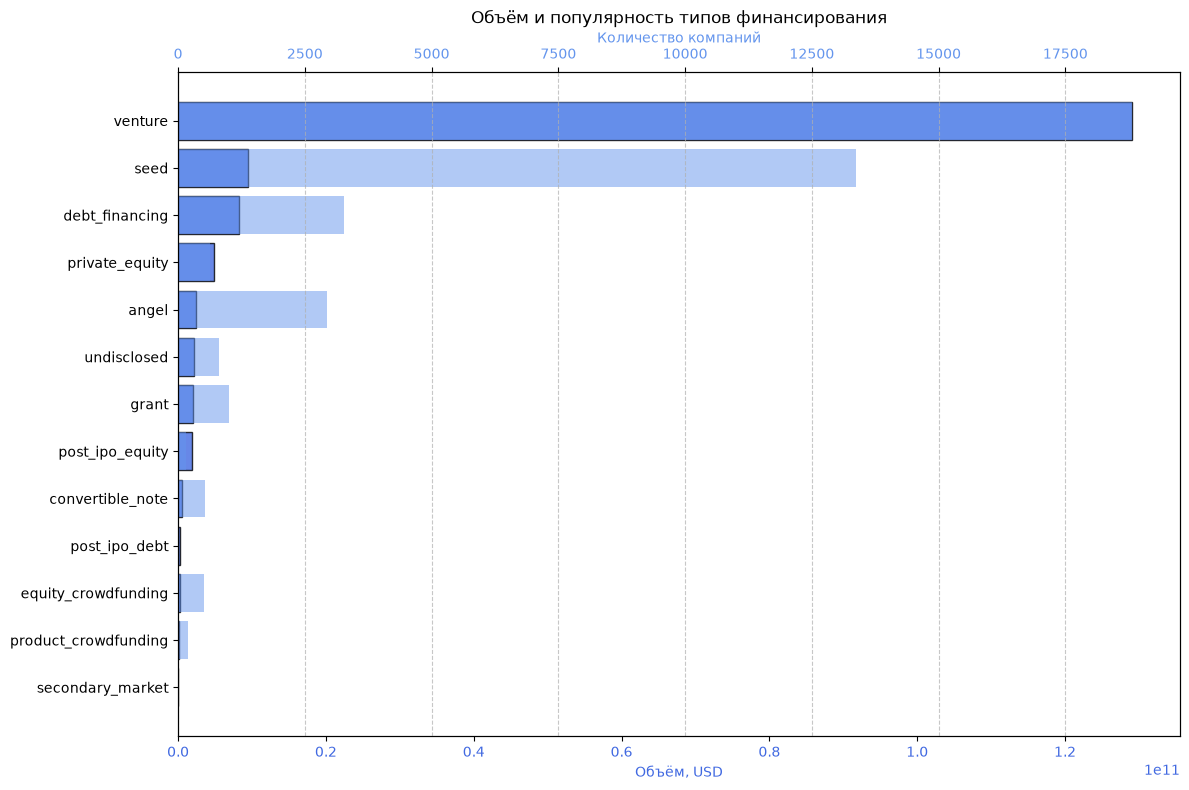

In [51]:
fig, ax1 = plt.subplots(figsize=(12, 8))

# Сортировка по объёму
funding_sums_sorted = funding_sums.sort_values(ascending=True)
funding_popularity_sorted = funding_popularity.reindex(funding_sums_sorted.index)

# Ось 1 — объём
ax1.barh(funding_sums_sorted.index, funding_sums_sorted.values, 
         color='royalblue', edgecolor='black', alpha=0.8, label='Объём')
ax1.set_xlabel('Объём, USD', color='royalblue')
ax1.tick_params(axis='x', labelcolor='royalblue')

# Ось 2 — популярность
ax2 = ax1.twiny()
ax2.barh(funding_popularity_sorted.index, funding_popularity_sorted.values, 
         color='cornflowerblue', alpha=0.5, label='Популярность')
ax2.set_xlabel('Количество компаний', color='cornflowerblue')
ax2.tick_params(axis='x', labelcolor='cornflowerblue')

plt.title('Объём и популярность типов финансирования')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() #'royalblue', 'cornflowerblue', 'lightblue'

In [52]:
# Сводная таблица
comparison = pd.DataFrame({
    'Объём': funding_sums,
    'Популярность': funding_popularity
}).sort_values('Объём', ascending=False)

print(comparison)

                                  Объём  Популярность
venture              129,092,208,088.00         18820
seed                   9,431,331,895.00         13375
debt_financing         8,178,152,734.00          3265
private_equity         4,843,108,504.00           634
angel                  2,481,263,836.00          2937
undisclosed            2,100,352,252.00           813
grant                  1,978,848,688.00          1003
post_ipo_equity        1,946,452,068.00           164
convertible_note         566,039,436.00           521
post_ipo_debt            286,718,349.00            27
equity_crowdfunding      237,960,645.00           515
product_crowdfunding     186,093,920.00           204
secondary_market          45,285,796.00             7


Исходя из полученных значений часто используются, но дают малый объём: `seed`, `angel`, `grant`, `equity_crowdfunding`, `product_crowdfunding`.

Редко встречаются, но дают большой объём: `debt_financing`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`. Эти типы используются реже, но привлекают значительные суммы.

Лидер по обоим показателям: `venture` самый популярный (18 820 компаний) и самый крупный по объёму (129 млрд.)

4. Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [53]:
# Суммы возвратов по типам за весь период
returns_sums = df_ret.sum().sort_values(ascending=True)
returns_sums

grant                       0.00
product_crowdfunding        1.86
equity_crowdfunding         3.83
secondary_market            5.20
convertible_note           34.79
post_ipo_debt              91.03
undisclosed               730.88
post_ipo_equity         1,104.96
angel                   1,509.23
seed                    2,382.24
private_equity          3,587.33
debt_financing          4,734.85
venture                40,578.62
dtype: float64

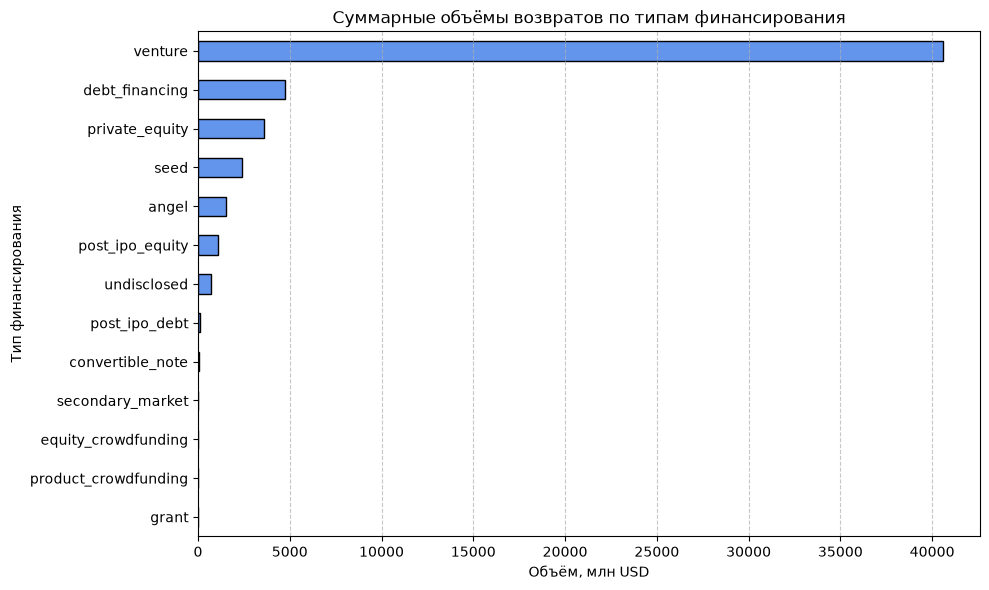

In [54]:
# График
plt.figure(figsize=(10, 6))
returns_sums.plot(kind='barh', color='cornflowerblue', edgecolor='black')
plt.title('Суммарные объёмы возвратов по типам финансирования')
plt.xlabel('Объём, млн USD')
plt.ylabel('Тип финансирования')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

`venture` абсолютный лидер по возвратам: 40 578 млн USD за весь период. С большим отрывом от остальных. Затем идут `debt_financing` и `private_equity`.

Средние по возвратам: `seed`, `angel`, `post_ipo_equity`, `undisclosed` (от 1 000 до 3 000 млн).

Минимальные возвраты у `convertible_note`, `secondary_market`, `equity_crowdfunding`, `product_crowdfunding`, `grant` (0, так как гранты не подразумевают возврата).

<a id="step4"></a>
## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

1. Рассчитаем средний объем одного раунда финансирования:

In [55]:
# Средний объём одного раунда
df_new['avg_round'] = df_new['funding_total_usd'] / df_new['funding_rounds']
df_new[['funding_total_usd', 'funding_rounds', 'avg_round']].head()

,funding_total_usd,funding_rounds,avg_round
1,"2,000,000.00",1.00,"2,000,000.00"
2,"9,000,000.00",1.00,"9,000,000.00"
3,"7,700,000.00",3.00,"2,566,666.67"
4,"540,000.00",1.00,"540,000.00"
7,"8,700,000.00",1.00,"8,700,000.00"


2. Для визуализации динамики типичного размера средств используем медианное значение среднего объема одного раунда за год, также отобразим на графике динамику общего количества раундов за каждый год.

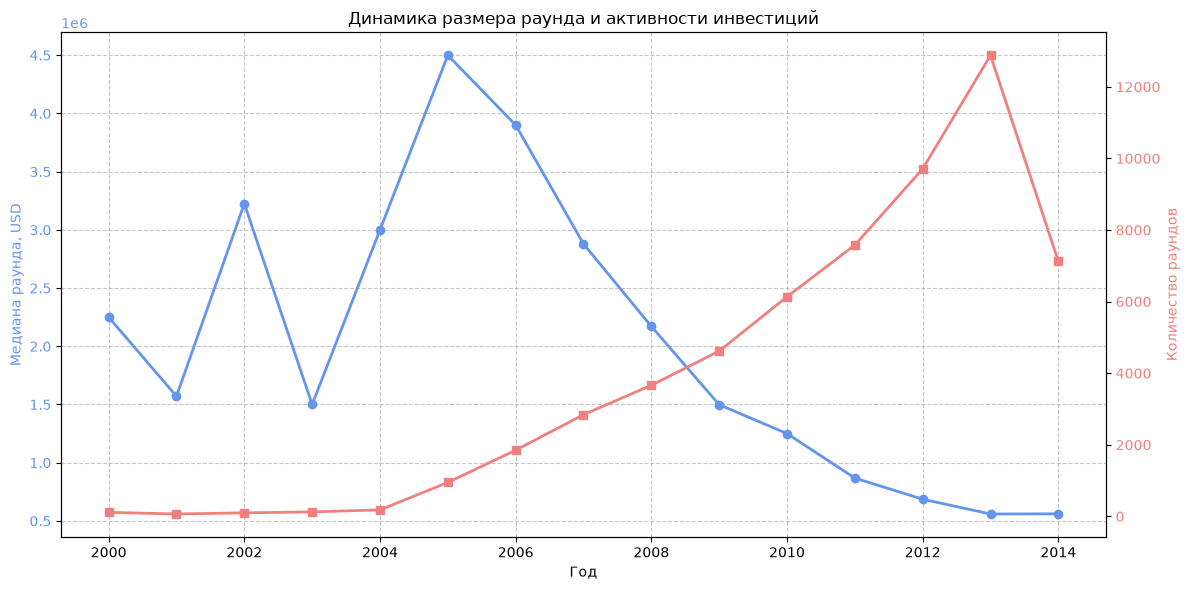

In [56]:
# Группировка по годам
by_year = df_new.groupby(df_new['mid_funding_at'].dt.year).agg({
    'avg_round': 'median',
    'funding_rounds': 'sum'
})

fig, ax1 = plt.subplots(figsize=(12, 6))

# Ось 1 — размер раунда
ax1.plot(by_year.index, by_year['avg_round'], 
         marker='o', color='cornflowerblue', linewidth=2, label='Медиана раунда')
ax1.set_xlabel('Год')
ax1.set_ylabel('Медиана раунда, USD', color='cornflowerblue')
ax1.tick_params(axis='y', labelcolor='cornflowerblue')
ax1.grid(linestyle='--', alpha=0.7)

# Ось 2 — количество раундов
ax2 = ax1.twinx()
ax2.plot(by_year.index, by_year['funding_rounds'], 
         marker='s', color='lightcoral', linewidth=2, label='Количество раундов')
ax2.set_ylabel('Количество раундов', color='lightcoral')
ax2.tick_params(axis='y', labelcolor='lightcoral')

plt.title('Динамика размера раунда и активности инвестиций')
plt.tight_layout()
plt.show()

2005 год - пик по размеру раунда.

С 2005 по 2014 - постепенное снижение медианы раунда.

С 2000 по 2013 - рост количества раундов.

2014 - первое резкое падение активности.

Рынок венчурных инвестиций рос по количеству сделок до 2013 года, но средний чек при этом падал, инвестиции становились мельче, но массовее. В 2014 году наметился перелом: активность упала, а размер раунда стабилизировался, это может быть из-за неполноты предоставленных данных.

*Важное допущение: медиана `avg_round` рассчитана по компаниям, а не по раундам. Компания с одним раундом весит столько же, сколько компания с пятьюдесятью. Это осознанный выбор, чтобы показать типичный размер раунда для компании за год, а не для отдельной сделки. При расчёте по раундам картина могла бы отличаться в сторону более крупных сделок, так как крупные компании генерируют больше раундов.*

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

1. Составим сводную таблицу, осталяем в ней только массовые сегменты, убираем заглушки:

In [57]:
# Сводная таблица: строки - годы, столбцы - сегменты
pivot = df_new.pivot_table(
    index=df_new['mid_funding_at'].dt.year,
    columns='market',
    values='funding_total_usd',
    aggfunc='sum',
    fill_value=0
)
pivot.index = pivot.index.astype(int)
 
#Оставляем только массовые сегменты (убираем заглушки)
pivot = pivot.drop(columns=['mid', 'niche', 'unknown'], errors='ignore')
 
#Отбираем сегменты, где 2014 > 2013
growing_markets = pivot.columns[pivot.loc[2014] > pivot.loc[2013]].tolist()
print(f"Массовых сегментов: {pivot.shape[1]}, выросло в 2014: {len(growing_markets)}")
print(growing_markets)

Массовых сегментов: 48, выросло в 2014: 10
['apps', 'big data', 'design', 'internet', 'manufacturing', 'medical', 'real estate', 'saas', 'startups', 'technology']


In [58]:
summary = pd.DataFrame({
    '2013': pivot.loc[2013, growing_markets],
    '2014': pivot.loc[2014, growing_markets]
})
summary['Прирост, USD'] = summary['2014'] - summary['2013']
summary['Прирост, %'] = ((summary['2014'] / summary['2013'] - 1) * 100).round(1)
summary.sort_values('Прирост, %', ascending=False)

,2013,2014,"Прирост, USD","Прирост, %"
market,,,,
medical,"64,469,424.00","175,236,064.00","110,766,640.00",171.80
startups,"18,080,552.00","41,501,837.00","23,421,285.00",129.50
apps,"28,868,621.00","66,237,730.00","37,369,109.00",129.40
internet,"69,732,096.00","117,830,756.00","48,098,660.00",69.00
technology,"120,873,887.00","202,018,937.00","81,145,050.00",67.10
real estate,"92,207,655.00","115,567,364.00","23,359,709.00",25.30
saas,"79,576,613.00","92,807,752.00","13,231,139.00",16.60
design,"60,958,835.00","68,988,516.00","8,029,681.00",13.20
manufacturing,"393,936,634.00","416,332,314.00","22,395,680.00",5.70


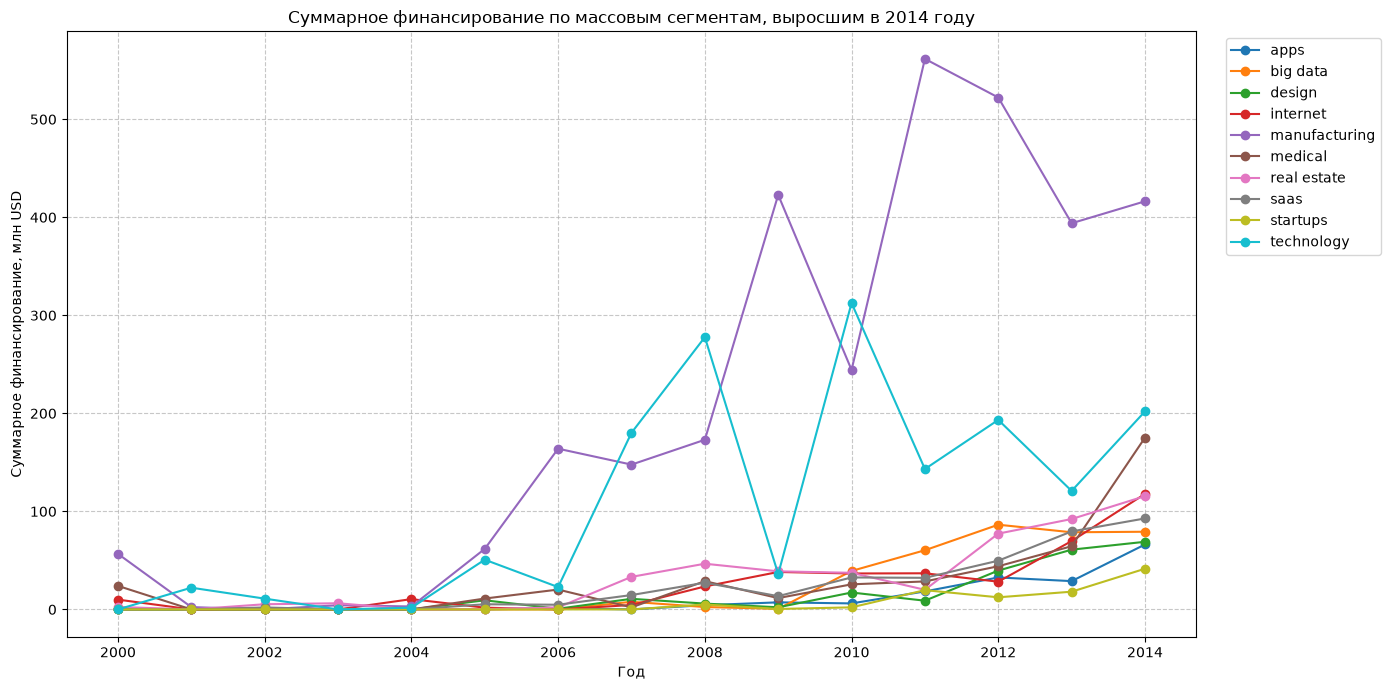

In [59]:
# Строим график
plt.figure(figsize=(14, 7))
for i, market in enumerate(growing_markets):
    plt.plot(
        pivot.index,
        pivot[market] / 1e6,  # в млн USD
        marker='o',
        label=market
    )

plt.title('Суммарное финансирование по массовым сегментам, выросшим в 2014 году')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование, млн USD')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

В 2014 году финансирование выросло в 10 массовых сегментах. Быстрее всех растут `medical` (+171,8%), `startups` (+129,5%) и `apps` (+129,4%), причём `medical` лидирует и по абсолютному приросту (+110,8 млн USD). Однако, рост `medical` подтверждён только одним годом, а `big data` (+0,7%) и `manufacturing` (+5,7%) находятся в состоянии застоя.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

1. Рассчитаем для каждого года и вида финансирования нормированные значения возврата средств, отсекая аномальные значения.

In [60]:
funding_by_year = df_new.groupby(df_new['mid_funding_at'].dt.year)[funding_types].sum()
funding_by_year.index = funding_by_year.index.astype(int)
returns_by_year = df_ret.loc[funding_by_year.index, funding_types] * 1e6
# Доли возврата (защита от нуля в знаменателе)
returns_ratio = returns_by_year / (funding_by_year+1e-60)
# Отсечем только физически невозможные значения (доля возврата > 1000%),
returns_ratio_clean = returns_ratio.mask(returns_ratio > 10)

returns_ratio.round(4)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
mid_funding_at,,,,,,,,,,,,,
2000,1.00,0.17,0.00,0.70,0.00,0.62,0.27,0.00,0.00,0.27,0.00,0.03,0.00
2001,1.08,0.11,0.00,0.59,0.01,0.77,1.18,0.00,0.00,"460,000,000,000,000,001,038,382,920,363,605,052...",0.00,"460,000,000,000,000,001,038,382,920,363,605,052...",0.00
2002,0.63,0.68,0.00,0.61,"20,000,000,000,000,000,426,408,380,189,087,937,...",0.22,1.14,0.00,0.20,1.13,0.00,"60,000,000,000,000,004,202,228,415,229,069,648,...",0.00
2003,0.51,0.63,0.00,0.91,"10,000,000,000,000,000,213,204,190,094,543,968,...",1.04,0.61,0.00,"1,620,000,000,000,000,019,924,062,422,007,093,7...","2,110,000,000,000,000,069,831,611,944,574,127,0...",0.00,"80,000,000,000,000,001,705,633,520,756,351,749,...",0.00
2004,0.55,0.84,0.00,0.53,"10,000,000,000,000,000,213,204,190,094,543,968,...",0.44,0.83,0.00,"2,190,000,000,000,000,200,149,389,550,449,935,5...","3,380,000,000,000,000,267,904,235,654,296,852,4...",0.00,"550,000,000,000,000,054,109,777,937,796,102,907...",0.00
2005,0.67,0.55,0.00,1.07,"20,000,000,000,000,000,426,408,380,189,087,937,...",0.34,0.51,0.00,0.48,0.73,0.00,"50,000,000,000,000,005,450,525,862,465,428,598,...",0.00
2006,0.93,0.34,0.20,0.76,0.17,0.80,0.67,0.00,0.94,"20,580,000,000,000,002,096,117,079,947,815,396,...",0.00,"120,000,000,000,000,008,404,456,830,458,139,297...",0.00
2007,0.37,0.30,"10,000,000,000,000,000,213,204,190,094,543,968,...",0.51,0.23,0.60,0.82,0.00,0.58,2.03,0.00,"569,999,999,999,999,993,153,117,550,087,268,280...",0.00
2008,0.30,0.19,"30,000,000,000,000,002,101,114,207,614,534,824,...",0.34,0.06,0.93,0.41,0.00,0.68,2.34,0.00,"470,000,000,000,000,017,328,105,121,098,081,121...",0.00


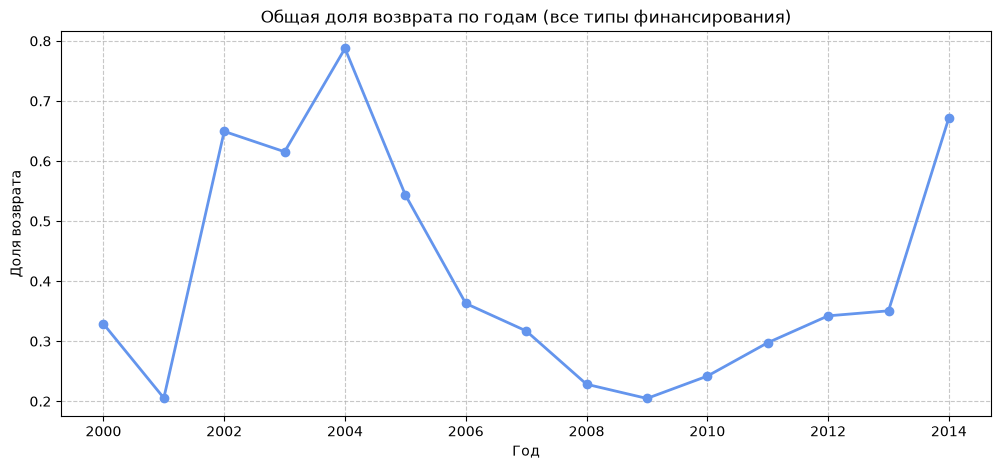

In [61]:
total_ratio = returns_by_year.sum(axis=1) / (funding_by_year.sum(axis=1) + 1e-60)

plt.figure(figsize=(12, 5))
plt.plot(total_ratio.index, total_ratio.values,
         marker='o', color='cornflowerblue', linewidth=2)
plt.title('Общая доля возврата по годам (все типы финансирования)')
plt.xlabel('Год')
plt.ylabel('Доля возврата')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

2. Построим график, на котором будут отображены нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

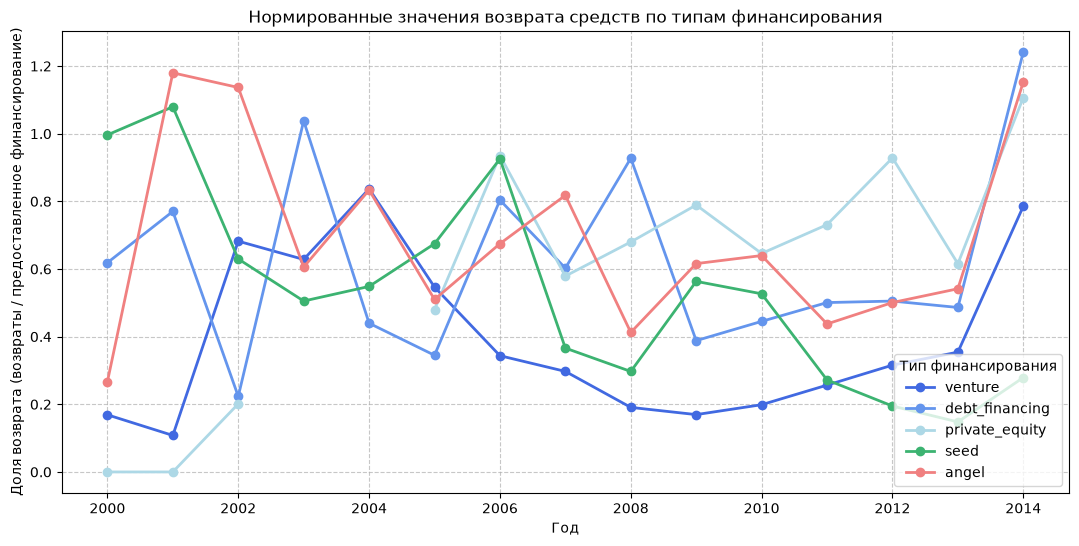

In [62]:
# Типы для отображения
plot_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Цвета в стиле палитры
colors = ['royalblue', 'cornflowerblue', 'lightblue', 'mediumseagreen', 'lightcoral']

plt.figure(figsize=(13, 6))

for col, color in zip(plot_types, colors):
    plt.plot(
        returns_ratio_clean.index,
        returns_ratio_clean[col],
        marker='o',
        linewidth=2,
        color=color,
        label=col
    )

plt.title('Нормированные значения возврата средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата (возвраты / предоставленное финансирование)')
plt.legend(title='Тип финансирования')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

Ни один из рассмотренных типов финансирования не демонстрирует устойчивого роста нормированного возврата: все ряды сильно колеблются год к году. venture показывает V-образную динамику - провал в 2008–2009 и восстановление к 2014, но разброс значений очень велик (от 0,11 до 0,84). seed демонстрирует нисходящий тренд с 2001 по 2013 год. debt_financing и angel - наиболее волатильны, с резкими одиночными пиками. Скачок 2014 года по всем типам, вероятно, связан с неполнотой данных за этот год и не может считаться устойчивым трендом.

<a id="step5"></a>
## Шаг 5. Итоговый вывод и рекомендации

#### Рекомендации на 2015 год

- Можно инвестировать в сегмент `medical`, так как он показал самый быстрый рост среди массовых сегментов: в 2014 году суммарное финансирование выросло на 171,8% (с 64,5 до 175,2 млн USD), а по абсолютному приросту (+110,8 млн USD) он тоже первый.

- `startups` и `apps` растут сопоставимо с `medical` (+129,5% и +129,4%), и вкладываться в них можно. Но это не долгосрочные вложения, так как чаще всего стартапы живут 2–3 года, а приложения устаревают за месяцы. Это ставка на быстрый оборот, а не на устойчивый рост.

- `manufacturing` - лидер по абсолютному объёму (416 млн USD), но его рост (+5,7%) близок к нулю, он подходит для стабильных, низкорисковых вложений.

- По типу финансирования для всех рассмотренных сегментов подходит `venture`, оно ориентировано на растущие компании с высоким потенциалом и способно работать как с длинным горизонтом (`medical`), так и с коротким (`startups`, `apps`), а также с крупными зрелыми игроками (`manufacturing`).

*Рекомендация предварительная, данные за 2014 год неполные, а рост подтверждён одним годом. Для окончательного решения нужны полные данные за 2014 год и более длинный период наблюдений.*

#### Итоги проекта

- Данные загружены и очищены: удалены пустые строки и записи без данных о финансировании, приведены типы и названия столбцов.

- Компании разделены по срокам финансирования, а рынки по размеру сегментов (массовые, средние, нишевые).

- Найдены и исключены аномальные компании по методу IQR, оставлены годы с 50+ раундами.

- Проведено сравнение типов финансирования по объёму, популярности и возвратам.

- Проанализирована динамика по годам: размер раунда, число раундов, рост сегментов, доля возвращённых средств.

#### Основные выводы

- 59% компаний получили финансирование один раз, но 62% всех денег пришлось на компании, которые финансировались дольше года.

- `venture` лидер по объёму и по числу компаний.

- В 2014 году финансирование выросло в 10 массовых сегментах, быстрее всех в `medical`, `startups` и `apps`.

- Устойчивого роста доли возвратов нет ни у одного из пяти рассмотренных типов: у `venture` провал в 2008–2009 годах и восстановление к 2014, у `seed` спад, у остальных резкие колебания.

**Насколько выводы согласуются и что вызывает сомнения**

- Выбор `venture` поддерживается объёмом и популярностью, но по возвратам устойчивого лидера нет.

- Данные за 2014 год неполные (по помесячной проверке в 3.2), поэтому падение числа раундов и скачок доли возвратов в 2014 году, вероятно, вызваны этим, а не реальным изменением рынка.

- `medical` — один из самых небольших массовых сегментов (151 компания при пороге 120). По объёму финансирования в 2014 году он уступает `technology` (202 млн) и `manufacturing` (416 млн), а высокий процент роста получен от небольшой базы.

- Возвраты относятся ко всему рынку, а вложения посчитаны по отфильтрованным данным, и к тому же возвраты года относятся к более ранним инвестициям. Поэтому доли возврата приблизительные, а у некоторых типов они больше 1.

- Рекомендация основана на данных до 2014 года и не является прогнозом.
